In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [8]:

rfm = pd.read_csv(r"C:\Users\acer\Downloads\GitHub\python-program\notebooks\rfm_features.csv")
df = pd.read_csv(r"C:\Users\acer\Downloads\GitHub\python-program\notebooks\transactions.csv")
users = pd.read_csv(r"C:\Users\acer\Downloads\GitHub\python-program\notebooks\users.csv")
df.shape
df.info()
df.describe()
df.head()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_id               20000 non-null  str    
 1   user_id                      20000 non-null  str    
 2   receiver_id                  20000 non-null  str    
 3   receiver_type                20000 non-null  str    
 4   amount                       20000 non-null  float64
 5   timestamp                    20000 non-null  str    
 6   date                         20000 non-null  str    
 7   hour_of_day                  20000 non-null  int64  
 8   day_of_week                  20000 non-null  str    
 9   is_weekend                   20000 non-null  int64  
 10  is_night_transaction         20000 non-null  int64  
 11  time_since_last_txn_min      17665 non-null  float64
 12  transaction_type             20000 non-null  str    
 13  payment_app                

np.int64(0)

In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [10]:
snapshot_date = df['timestamp'].max() + pd.Timedelta(days=1)
print(snapshot_date)

2024-12-31 22:31:52


In [11]:
rfm = df.groupby('user_id').agg({
    'timestamp': lambda x: (snapshot_date - x.max()).days,
    'transaction_id': 'count',
    'amount': 'sum'
}).reset_index()

In [12]:
rfm.columns = ['user_id', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,user_id,Recency,Frequency,Monetary
0,USR00001,9,11,10597.11
1,USR00002,57,7,3444.34
2,USR00003,76,8,3195.66
3,USR00004,14,10,2706.06
4,USR00005,43,8,8672.13


In [13]:
rfm['Avg_Txn_Value'] = rfm['Monetary'] / rfm['Frequency']

In [14]:
df['is_weekend'] = df['timestamp'].dt.dayofweek >= 5

weekend_ratio = df.groupby('user_id')['is_weekend'].mean()

rfm = rfm.merge(
    weekend_ratio.rename('Weekend_Ratio'),
    on='user_id'
)

In [15]:
df['hour'] = df['timestamp'].dt.hour

df['is_night'] = (
    (df['hour'] >= 22) |
    (df['hour'] <= 5)
)

night_ratio = df.groupby('user_id')['is_night'].mean()

rfm = rfm.merge(
    night_ratio.rename('Night_Ratio'),
    on='user_id'
)

In [16]:
rfm['user_loyalty_score'] = (
    rfm['Frequency'] * 0.5 +
    rfm['Monetary'] * 0.5
)
rfm.head()
rfm.shape
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             2000 non-null   str    
 1   Recency             2000 non-null   int64  
 2   Frequency           2000 non-null   int64  
 3   Monetary            2000 non-null   float64
 4   Avg_Txn_Value       2000 non-null   float64
 5   Weekend_Ratio       2000 non-null   float64
 6   Night_Ratio         2000 non-null   float64
 7   user_loyalty_score  2000 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 125.1 KB


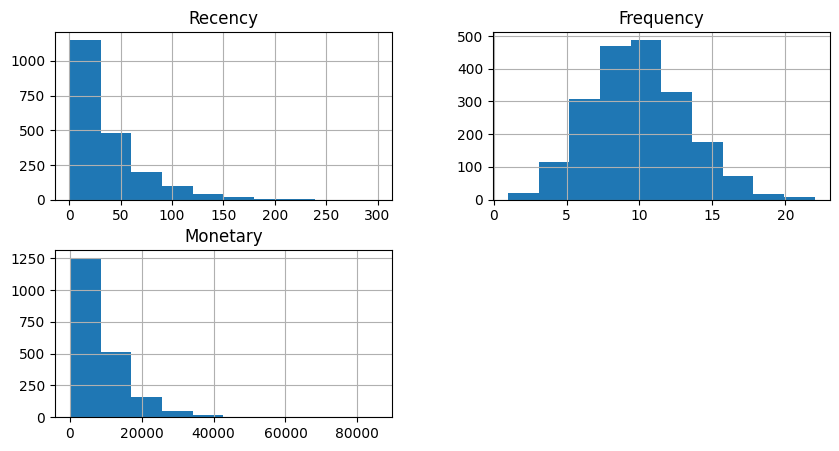

In [17]:
rfm[['Recency','Frequency','Monetary']].hist(
    figsize=(10,5)
)
plt.show()

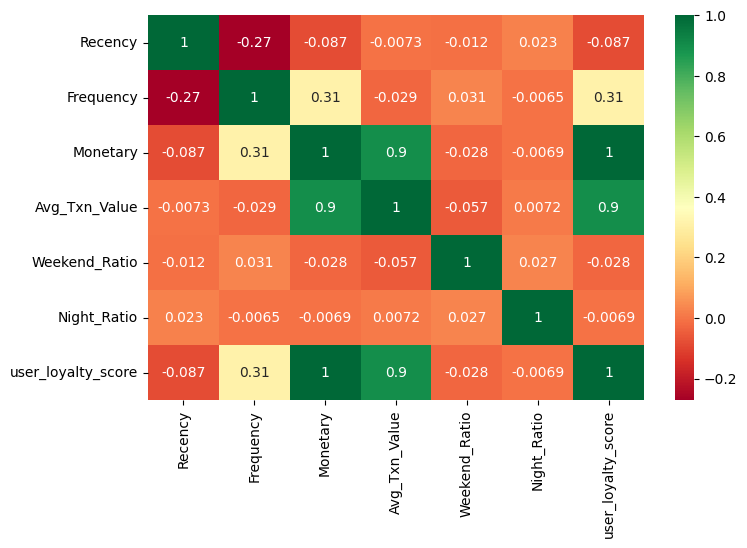

In [18]:
plt.figure(figsize=(8,5))

sns.heatmap(
    rfm.corr(numeric_only=True),
    annot=True,
    cmap='RdYlGn'
)

plt.show()

In [19]:
rfm.skew(numeric_only=True)

Recency               1.892425
Frequency             0.299385
Monetary              2.384292
Avg_Txn_Value         2.897814
Weekend_Ratio         0.518591
Night_Ratio           0.375527
user_loyalty_score    2.383711
dtype: float64

In [20]:
from sklearn.preprocessing import StandardScaler

features = [
    'Recency',
    'Frequency',
    'Monetary',
    'Avg_Txn_Value',
    'Weekend_Ratio',
    'Night_Ratio'
]

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[features]
)

print(rfm_scaled.shape)

(2000, 6)


In [21]:
rfm.to_csv(
    "rfm_features.csv",
    index=False
)